> ⏸️ **Parked.** Этот ноутбук — гранула `(hour, location)`: «сколько аренд на конкретном киоске
> в этот час» (~365K строк). По решению ментора основная задача переключена на **почасовой тотал**
> по всему городу — она в [eda_and_modeling.ipynb](eda_and_modeling.ipynb). Здесь работа сохранена
> как наброски (baseline → #1 Ridge → #2 conditions → #3 RandomForest на per-location); возможно,
> вернёмся к ней позже (ребалансировка между киосками — отдельная бизнес-задача).

# Bike Rentals: Modeling

## Objective

---

This notebook picks up from the raw data explored in `eda_and_preprocessing.ipynb` (week 2).
It rebuilds the combined hourly dataset — the same logic as the Dagster pipeline — so that
feature engineering changes can be prototyped here before moving to the pipeline.

Then:

1. Exploratory analysis of the prepared dataset (target distribution, feature–target relationships)
2. Baseline regression model
3. Iterative model improvement (feature engineering, model selection)
4. Results and conclusions for pipeline integration

## Imports & Setup

---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATETIME_FORMAT = "ISO8601"
LAUNCH_DATE = pd.Timestamp("2011-01-01")  # начало наблюдений → отсчёт тренда

## Load Raw Sources

---

In [2]:
DATA_RAW = Path("../data/raw")

registered_rentals_data = pd.read_csv(DATA_RAW / "registered_bike_rentals.csv")
direct_rentals_data    = pd.read_csv(DATA_RAW / "direct_pickup_bike_rentals.csv")
weather_data           = pd.read_csv(DATA_RAW / "weather.csv")
holiday_calendar_data  = pd.read_csv(DATA_RAW / "holidays.csv")

## Build Combined Dataset

---

Mirrors the Dagster pipeline logic. Data quality decisions (near-duplicates kept,
humidity sensor fix, ordinal weather encoding) are documented in `eda_and_preprocessing.ipynb`.

### Hourly rental counts per location

In [3]:
rentals = pd.concat([
    registered_rentals_data.assign(is_registered=True),
    direct_rentals_data.assign(is_registered=False),
], ignore_index=True)
rentals["datetime_hourly"] = pd.to_datetime(rentals["datetime"], format=DATETIME_FORMAT).dt.floor("h")

reg_counts = (
    rentals[rentals["is_registered"]]
    .groupby(["datetime_hourly", "location_id"]).size()
    .reset_index(name="registered_rentals")
)
direct_counts = (
    rentals[~rentals["is_registered"]]
    .groupby(["datetime_hourly", "location_id"]).size()
    .reset_index(name="direct_pickups")
)

all_hours = sorted(rentals["datetime_hourly"].unique())
all_locations = sorted(rentals["location_id"].unique())
full_grid = pd.merge(
    pd.DataFrame({"datetime_hourly": all_hours}),
    pd.DataFrame({"location_id": all_locations}),
    how="cross",
)

hourly_rentals = (
    full_grid
    .merge(reg_counts, on=["datetime_hourly", "location_id"], how="left")
    .merge(direct_counts, on=["datetime_hourly", "location_id"], how="left")
    .fillna(0)
    .astype({"registered_rentals": int, "direct_pickups": int})
)
hourly_rentals["total_rentals"] = (
    hourly_rentals["registered_rentals"] + hourly_rentals["direct_pickups"]
)

### Time features

`days_since_launch` — дни с начала наблюдений (2011-01-01) — фича тренда роста сервиса
(см. [exploration_time_trends.ipynb](exploration_time_trends.ipynb)). Все признаки здесь —
детерминированные построчные производные от `datetime_hourly`, лика нет → их место в `final_dataset`.

In [4]:
dt = hourly_rentals["datetime_hourly"]
hourly_rentals["month"]            = dt.dt.month
hourly_rentals["hour_of_day"]      = dt.dt.hour
hourly_rentals["day_of_week"]      = dt.dt.dayofweek
hourly_rentals["is_weekend"]       = (dt.dt.dayofweek >= 5).astype(int)
hourly_rentals["days_since_launch"] = (dt.dt.normalize() - LAUNCH_DATE).dt.days

### Weather (with humidity fix and conditions encoding)

In [5]:
WEATHER_SEVERITY = {"clear": 0, "clouds": 1, "light_rain": 2, "heavy_rain": 3}

clean_weather = weather_data.copy()
clean_weather["datetime_hourly"] = pd.to_datetime(clean_weather["datetime"], format=DATETIME_FORMAT).dt.floor("h")

clean_weather["humidity"] = clean_weather["humidity"].replace(0, np.nan)
clean_weather["humidity"] = clean_weather["humidity"].interpolate("linear")

clean_weather["conditions"] = clean_weather["conditions"].map(WEATHER_SEVERITY)

clean_weather = clean_weather.drop(columns=["datetime", "id"])

### Join & holiday flag

In [6]:
dataset = hourly_rentals.merge(clean_weather, on="datetime_hourly", how="left")

holiday_dates = set(pd.to_datetime(holiday_calendar_data["date"], format=DATETIME_FORMAT).dt.date)
dataset["is_holiday"] = dataset["datetime_hourly"].dt.date.isin(holiday_dates).astype(int)

### Sanity check

In [7]:
raw_events_total = len(registered_rentals_data) + len(direct_rentals_data)
assert dataset["total_rentals"].sum() == raw_events_total, "rental count mismatch!"
assert dataset.notna().all().all(), "unexpected NaN!"

print(f"Shape: {dataset.shape}")
dataset.info()
print()
dataset.head()

Shape: (364959, 16)
<class 'pandas.DataFrame'>
RangeIndex: 364959 entries, 0 to 364958
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   datetime_hourly          364959 non-null  datetime64[us]
 1   location_id              364959 non-null  int64         
 2   registered_rentals       364959 non-null  int64         
 3   direct_pickups           364959 non-null  int64         
 4   total_rentals            364959 non-null  int64         
 5   month                    364959 non-null  int32         
 6   hour_of_day              364959 non-null  int32         
 7   day_of_week              364959 non-null  int32         
 8   is_weekend               364959 non-null  int64         
 9   days_since_launch        364959 non-null  int64         
 10  conditions               364959 non-null  int64         
 11  temperature_c            364959 non-null  float64       
 12  perceiv

,datetime_hourly,location_id,registered_rentals,direct_pickups,total_rentals,month,hour_of_day,day_of_week,is_weekend,days_since_launch,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,is_holiday
0,2011-01-01,0,0,0,0,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
1,2011-01-01,1,0,0,0,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
2,2011-01-01,2,0,1,1,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
3,2011-01-01,3,1,0,1,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
4,2011-01-01,4,2,0,2,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0


## Идеи и открытые вопросы

---

*Каждая группа исследуется в отдельном ноутбуке.*

---

### Данные и таргет

**Рост сервиса и временной тренд** | [exploration_time_trends.ipynb](exploration_time_trends.ipynb)
- Headline-рост +65% год к году, но **двухрежимный**: фаза запуска (≈ янв–апр 2011, адопция почти с нуля) и органический режим (с мая 2011, рост ~+52%).
- Фича тренда — **`days_since_launch`** (дни с 2011-01-01), а не `year`: ловит и межгодовой сдвиг, и внутригодовую рампу 2011-го; для линейных моделей это рампа, а не ступенька. За 2013+ не экстраполирует ни она, ни `year` (у деревьев — стена).
- Фаза запуска — разовый неповторяющийся артефакт. Дропать ли её строки из обучения — решаем **экспериментом** (с ними и без), а не вслепую.

**Один таргет или два?**
- `total_rentals` = `registered_rentals` + `direct_pickups`.
- Сегменты разные: registered в 4.3x больше по объёму, вероятно другой поведенческий паттерн.
- Варианты: (a) один таргет `total_rentals`, (b) два отдельных таргета и суммировать, (c) ratio registered/direct как фича.
- Стоит проверить: корреляция остатков двух моделей — если сильная, смысла в разделении нет.

**Гранулярность предсказания**
- Сейчас: `(hour, location_id)` — ~365k строк.
- Альтернатива: агрегировать до `(hour)` — ~17k строк.
- Если по `(hour, location_id)`: `location_id` — категориальный, нужно решить кодирование (one-hot / target encoding / ordinal). 21 уникальное значение — one-hot допустимо.

---

### Feature engineering

**Праздники** | [exploration_holidays.ipynb](exploration_holidays.ipynb)
- Бинарный `is_holiday` не различает зимние (семейные, спрос падает) и летние (активные, спрос растёт) праздники. Разброс: 1,000–7,400 аренд/день при среднем обычного дня ~4,500.
- Группировка праздников бесполезна: 1–2 наблюдения на группу, вариация внутри группы (~2,400) сопоставима с нормой (~1,500).
- Температура не объясняет разброс — гипотеза проверена и отвергнута.
- Рекомендация: **`is_holiday + days_since_launch + month`** — модель сама выучит взаимодействие.
- Открыто: влияет ли день недели праздника? Ведут ли себя registered и direct по-разному? Праздники начала 2011 стоит перепроверить на органическом режиме (вне фазы запуска).

**Погода**
- `conditions` закодирован ординально 0..3 (`clear < clouds < light_rain < heavy_rain`).
- `heavy_rain` — всего 3 наблюдения. Редкий класс, но ordinal encoding хранит его корректно.
- Humidity: сенсорный сбой (22 строки = 0%) исправлен интерполяцией.
- Открыто: нелинейные эффекты температуры (модель поедет больше в жару/холод, но не при 15°C)? Взаимодействие погоды и времени суток?

**Временные признаки**
- Сейчас: `month`, `hour_of_day`, `day_of_week`, `is_weekend` — raw integers.
- Для линейных моделей нужно cyclic encoding (sin/cos) для `hour_of_day`, `month`, `day_of_week` — иначе 23:00 и 00:00 «далеко», хотя рядом.
- Для деревьев raw integers работают — cyclic не нужен.
- **`days_since_launch`** — добавить как тренд-фичу (см. блок про рост и [trends](exploration_time_trends.ipynb)).

**Лаги и агрегаты (если останется время)**
- `total_rentals` за прошлый час / прошлую неделю в тот же час.
- Средний спрос по location за последние N дней.
- Осторожно с ликом: лаги допустимы, а вот будущее — нет. При time-aware split всё чисто.

---

### Обучение и оценка

**Split — решено: хронологический 70/30**
- train = первые 70% хронологии, test = последние 30%. Оба года и в train, и в test → рост «размазан», метрики меряют качество паттернов, а не ступеньку роста.
- train=2011/test=2012 — только как доп-проверка «прогноз следующего года» (метрики там занижены ростом — это ожидаемо).
- Обычный random split **нельзя** — лик по времени.

**Таргет**
- Рассмотреть **лог-таргет** `log1p(total_rentals)` для линейной модели: мультипликативный, сезонно-неравномерный рост в логе становится аддитивным. Деревьям не обязательно.

**Метрики**
- Основной набор: **MAE**, **RMSE**, **R²**.
- MAE — интерпретируемое число для бизнеса: «в среднем промах на N аренд/час/киоск».
- RMSE — штрафует большие промахи непропорционально. Хорошо для планирования, где крупный недопрогноз дорого стоит.
- R² — доля объяснённой дисперсии поверх mean baseline. Относительная мера.
- **MAPE — нельзя**, в таргете есть нули (тихие часы на киосках). Если нужна безразмерность — WAPE.
- Диагностика: **RMSE / MAE** ≈ 1 → ошибки однородные; >> 1 → есть хвост (пики vs нули).
- Считать в разрезах: по `hour_of_day`, `location_id`, `month`. Глобальная MAE = 5 может скрывать MAE = 50 на пиковых часах.

**Порядок моделей**
1. `Ridge` — baseline, быстрый, линейный.
2. `RandomForestRegressor` — сильный prior без тюнинга, ловит нелинейности.
3. `XGBRegressor` с early stopping — обычно лучший результат, но сложнее в настройке.
- Всё через `sklearn.Pipeline` + `ColumnTransformer`.

---

### Методология данных

- **Один базовый `final_dataset` для всех моделей:** одни и те же строки, таргет и split. Иначе сравнение моделей нечестное (сравниваешь датасеты, а не модели).
- **Представление фичей — под каждую модель,** внутри `sklearn.Pipeline` + `ColumnTransformer` (Ridge: scaling + cyclic + one-hot; деревья: raw integers). Это не разные датасеты, а разные обёртки над одним.
- **Граница «что куда»** (защита от лика):
  - детерминированные построчные производные (`month`, `hour_of_day`, `is_weekend`, `days_since_launch`) → можно класть в `final_dataset` (upstream, лика нет);
  - обучаемые трансформации (scaling, target/one-hot-словарь, импутация) → только внутри Pipeline, `fit` на train-фолде.
- **Менять по одному за раунд:** сравниваешь модели → фичи+split фиксированы; сравниваешь наборы фичей → модель+split фиксированы.

---

### Интеграция в Dagster (после моделирования)

- Новый asset `trained_model`: берёт `final_dataset`, делает split, обучает sklearn Pipeline, возвращает сериализованный объект.
- IO manager для `.joblib` (по аналогии с `csv_io.py`). Сохранять **всю Pipeline**, не только модель.
- Метаданные: метрики на test, версии sklearn/xgboost, размер модели.
- Новые фичи → расширить существующие data-assets или создать новые feature-assets.

## Baseline-модель: LinearRegression

---

Применяем решения из блока «Идеи и открытые вопросы»:

- таргет `total_rentals`, гранулярность `(hour, location_id)`;
- **хронологический сплит 70/15/15**, обучаем на train, меряем на validation;
- **самая простая модель** — `LinearRegression` через `Pipeline` + `ColumnTransformer`: cyclic-кодирование времени, one-hot для `location_id`, масштабирование числовых;
- **защита от лика:** `registered_rentals` и `direct_pickups` в сумме дают таргет — в признаки не идут.

Регуляризованные и нелинейные модели — дальше, в разделе «Улучшения», и только если оправданы результатом.

In [8]:
# Один базовый final_dataset для всех моделей: одни и те же строки, таргет и сплит.
# registered_rentals / direct_pickups исключены — это компоненты таргета (лик).
TARGET = "total_rentals"
FEATURES = [
    "month", "hour_of_day", "day_of_week", "is_weekend", "is_holiday",
    "conditions", "temperature_c", "perceived_temperature_c", "humidity",
    "windspeed_kmh", "days_since_launch", "location_id",
]
final_dataset = dataset[["datetime_hourly", *FEATURES, TARGET]].copy()
print(f"final_dataset: {final_dataset.shape},  признаков: {len(FEATURES)}")
final_dataset.head()

final_dataset: (364959, 14),  признаков: 12


,datetime_hourly,month,hour_of_day,day_of_week,is_weekend,is_holiday,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,days_since_launch,location_id,total_rentals
0,2011-01-01,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0,0,0
1,2011-01-01,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0,1,0
2,2011-01-01,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0,2,1
3,2011-01-01,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0,3,1
4,2011-01-01,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0,4,2


### Распределение таргета

Сильно скошено вправо, ~14% строк — нули (тихие часы на киосках). Из-за нулей **MAPE неприменима**.
Скошенность поднимает вопрос лог-таргета для линейной модели — проверим его экспериментом ниже.

mean=9.02  median=6  max=64  нулей=14.4%  skew=1.38


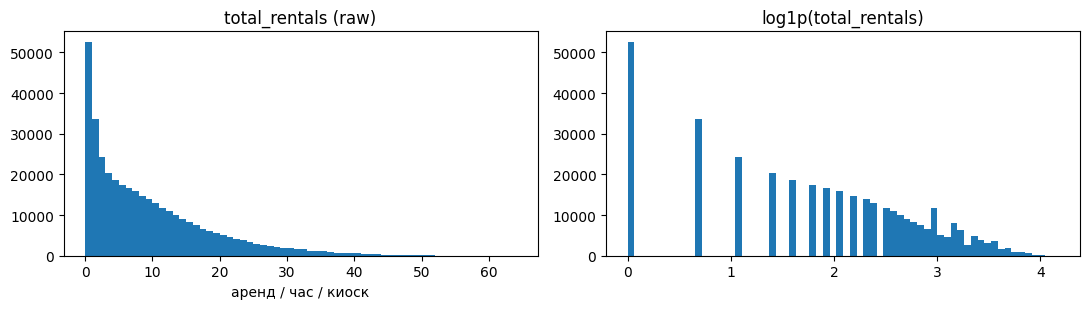

In [9]:
import matplotlib.pyplot as plt

y_all = final_dataset[TARGET]
print("mean=%.2f  median=%.0f  max=%d  нулей=%.1f%%  skew=%.2f"
      % (y_all.mean(), y_all.median(), y_all.max(), (y_all == 0).mean() * 100, y_all.skew()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(y_all, bins=64); ax[0].set_title("total_rentals (raw)"); ax[0].set_xlabel("аренд / час / киоск")
ax[1].hist(np.log1p(y_all), bins=64); ax[1].set_title("log1p(total_rentals)")
plt.tight_layout(); plt.show()

### Хронологический сплит 70/15/15

Строго по времени, по уникальным таймстампам (один час не дробим между частями). Роли:

- **train** (первые 70%) — обучаем модель;
- **validation** (15%) — здесь сравниваем фичи/модели и гоняем ablation;
- **test** (последние 15%) — held-out, трогаем **один раз в самом конце**, после выбора модели. До этого не смотрим, иначе подгоним решения под него (утечка теста в выбор).

train охватывает оба года; val и test — поздний 2012. Нюанс единственного тайм-сплита: val — лето, test — осень/зима (разные сезоны), поэтому val-метрики не идеально предсказывают test; от этого лечит time-series CV — добавим позже при необходимости.

In [10]:
# Сплит по уникальным таймстампам, строго по времени: train | val | test = 70 | 15 | 15.
ds = final_dataset.sort_values(["datetime_hourly", "location_id"]).reset_index(drop=True)
timestamps = np.sort(ds["datetime_hourly"].unique())
cut1 = timestamps[int(len(timestamps) * 0.70)]
cut2 = timestamps[int(len(timestamps) * 0.85)]

train = ds[ds["datetime_hourly"] < cut1]
val   = ds[(ds["datetime_hourly"] >= cut1) & (ds["datetime_hourly"] < cut2)]
test  = ds[ds["datetime_hourly"] >= cut2]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]   # held-out, до финала не трогаем

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5} {len(part):>7,} ({len(part) / len(ds):.0%})  "
          f"[{part['datetime_hourly'].min():%Y-%m-%d} … {part['datetime_hourly'].max():%Y-%m-%d}]")

train 255,465 (70%)  [2011-01-01 … 2012-05-27]
val    54,747 (15%)  [2012-05-27 … 2012-09-12]
test   54,747 (15%)  [2012-09-12 … 2012-12-31]


### Pipeline

Представление признаков — под линейную модель, внутри `ColumnTransformer` (обёртка над `final_dataset`, не новый датасет):

- `hour_of_day`, `month`, `day_of_week` → **cyclic (sin/cos)**, иначе 23:00 и 00:00 «далеко»;
- `location_id` → **one-hot** (21 значение);
- числовые (`conditions` ordinal, погода, `days_since_launch`) → **StandardScaler**;
- бинарные (`is_weekend`, `is_holiday`) → passthrough.

`make_linear(estimator)` собирает любую линейную модель поверх этого препроцессора; `log_target` оборачивает таргет в log1p/expm1. Обучаемые трансформации фитятся только на train-фолде — лика нет.

In [11]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


def cyclic(period):
    """sin/cos-кодирование циклического признака с заданным периодом."""
    return FunctionTransformer(
        lambda x, p=period: np.column_stack([np.sin(2 * np.pi * x / p), np.cos(2 * np.pi * x / p)]),
        feature_names_out="one-to-one",
    )


preprocess = ColumnTransformer([
    ("hour",  cyclic(24), ["hour_of_day"]),
    ("month", cyclic(12), ["month"]),
    ("dow",   cyclic(7),  ["day_of_week"]),
    ("loc",   OneHotEncoder(handle_unknown="ignore"), ["location_id"]),
    ("num",   StandardScaler(), ["conditions", "temperature_c", "perceived_temperature_c",
                                 "humidity", "windspeed_kmh", "days_since_launch"]),
    ("bin",   "passthrough", ["is_weekend", "is_holiday"]),
])


def make_linear(estimator, log_target=False):
    """Линейная модель поверх preprocess; log_target=True оборачивает таргет в log1p/expm1."""
    pipe = Pipeline([("pre", preprocess), ("model", estimator)])
    if log_target:
        return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return pipe

### Обучение и метрики

Набор: **MAE** (интерпретируемо — «промах на N аренд/час/киоск»), **RMSE** (штрафует крупные промахи),
**R²** (доля объяснённой дисперсии), **RMSE/MAE** (диагностика хвоста: ≈1 — однородно, >>1 — есть пики).
Baseline — `LinearRegression`. Обучаем на **train**, меряем на **validation** (test держим до финала).
Сравнение — с наивным baseline (среднее train). Прогноз клипуем снизу нулём.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2_score(y_true, y_pred), "RMSE/MAE": rmse / mae}


baseline = make_linear(LinearRegression())   # raw-таргет (обоснование ниже)
baseline.fit(X_train, y_train)
val_pred = np.clip(baseline.predict(X_val), 0, None)

results = pd.DataFrame({
    "LinearRegression (val)": evaluate(y_val, val_pred),
    "mean-baseline":          evaluate(y_val, np.full(len(y_val), y_train.mean())),
}).T
results.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression (val),7.123,9.054,0.348,1.271
mean-baseline,9.484,12.611,-0.264,1.330


### Лог-таргет vs raw

Скошенность таргета — аргумент за `log1p`. Проверяем экспериментом (модель и сплит фиксированы, меняем только таргет).

In [13]:
rows = {}
for name, log in [("raw target", False), ("log1p target", True)]:
    m = make_linear(LinearRegression(), log_target=log)
    m.fit(X_train, y_train)
    p = np.clip(m.predict(X_val), 0, None)
    rows[name] = evaluate(y_val, p)
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
raw target,7.123,9.054,0.348,1.271
log1p target,7.055,9.792,0.238,1.388


**Вывод:** `log1p` символически лучше по MAE, но проигрывает по **RMSE и R²**
(на validation raw R²≈0.35 против log1p≈0.24) — лог-таргет недооценивает пиковые часы, а они нам важны.
→ **baseline на raw-таргете.** (К лог-таргету вернёмся, если приоритетом станет MAE на низких счётчиках.)

### Разрезы ошибок (validation)

Глобальная MAE может скрывать узкие места. Смотрим по часам суток (где модель промахивается) и по киоскам (однородна ли ошибка).

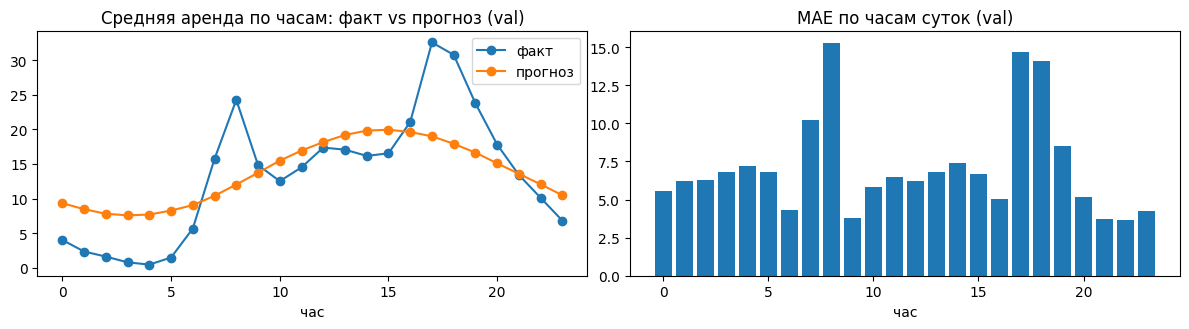

MAE по часам (худшие):
hour_of_day
8     15.27
17    14.68
18    14.08
7     10.21

MAE по киоскам: min=7.03  max=7.24  spread=0.21


In [14]:
val_eval = val.assign(pred=val_pred, abs_err=np.abs(y_val.values - val_pred))

by_hour = val_eval.groupby("hour_of_day").agg(
    MAE=("abs_err", "mean"), факт=(TARGET, "mean"), прогноз=("pred", "mean"))
by_loc = val_eval.groupby("location_id")["abs_err"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(by_hour.index, by_hour["факт"], marker="o", label="факт")
ax[0].plot(by_hour.index, by_hour["прогноз"], marker="o", label="прогноз")
ax[0].set_title("Средняя аренда по часам: факт vs прогноз (val)"); ax[0].set_xlabel("час"); ax[0].legend()
ax[1].bar(by_hour.index, by_hour["MAE"])
ax[1].set_title("MAE по часам суток (val)"); ax[1].set_xlabel("час")
plt.tight_layout(); plt.show()

print("MAE по часам (худшие):")
print(by_hour["MAE"].sort_values(ascending=False).head(4).round(2).to_string())
print(f"\nMAE по киоскам: min={by_loc.min():.2f}  max={by_loc.max():.2f}  "
      f"spread={by_loc.max() - by_loc.min():.2f}")

## Выводы baseline

---

- **LinearRegression бьёт наивный baseline** (на validation R²≈0.35 против отрицательного у предсказания среднего; MAE 7.1 vs 9.5): линейная модель ловит основной сигнал — часы, сезон, киоск, тренд `days_since_launch`.
- **RMSE/MAE≈1.27** → есть хвост: систематическая **недооценка пиковых часов** (утро ~8:00 и вечер 17–18:00) — видно на графике «факт vs прогноз». Это нелинейность и взаимодействия (час × будни, час × погода).
- **Лог-таргет** проигрывает raw по RMSE/R² → baseline на raw-таргете.
- Ошибка по киоскам **почти однородна** (spread ~0.2): one-hot по `location_id` уже впитал уровень киоска. Улучшать надо профиль по часам, не по локациям.
- **Test не трогали** — финальное число посчитаем один раз после выбора модели.

Дальше — раздел «Улучшения»: каждый шаг меняет одну вещь и обосновывается сравнением на validation.

## Улучшения

---

Каждый шаг — **одна вещь за раунд**, сравнение на **validation** (test не трогаем). Порядок «просто → сложнее»; усложняем только если оправдано результатом.

### #1. Регуляризация: Ridge

При **n ≫ p** (255k строк против ~40 признаков) регуляризации нечего стягивать → ожидаем no-op. Быстрая проверка на validation:

In [15]:
rows = {}
for name, est in [("LinearRegression", LinearRegression()),
                  ("Ridge(alpha=1)",   Ridge(alpha=1.0)),
                  ("Ridge(alpha=10)",  Ridge(alpha=10.0))]:
    m = make_linear(est)
    m.fit(X_train, y_train)
    rows[name] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression,7.123,9.054,0.348,1.271
Ridge(alpha=1),7.123,9.054,0.348,1.271
Ridge(alpha=10),7.123,9.054,0.348,1.271


Идентично до 3 знаков даже при alpha=10 → для нашего датасета регуляризация бесполезна, baseline `LinearRegression` остаётся. Реальная слабость — недооценка пиков (взаимодействия) → дальше деревья: **#3 `RandomForestRegressor`**, **#4 `XGBRegressor`**.

### #2. Кодирование `conditions`: ординал vs one-hot

Ординал (0..3 + scaler) навязывает линейной модели **равный шаг** между состояниями погоды
(clear→clouds = light_rain→heavy_rain). One-hot снимает это допущение — свой коэффициент на каждое состояние.
Проверяем, оправдан ли он. (`heavy_rain` редок: 63 строки на весь датасет, и все в train.)

In [16]:
# Два варианта препроцессора, отличаются только обработкой conditions.
WEATHER_NUM = ["temperature_c", "perceived_temperature_c", "humidity", "windspeed_kmh", "days_since_launch"]
common = [
    ("hour",  cyclic(24), ["hour_of_day"]),
    ("month", cyclic(12), ["month"]),
    ("dow",   cyclic(7),  ["day_of_week"]),
    ("loc",   OneHotEncoder(handle_unknown="ignore"), ["location_id"]),
    ("bin",   "passthrough", ["is_weekend", "is_holiday"]),
]


def preprocess_conditions(mode):
    if mode == "ordinal":
        steps = common + [("num", StandardScaler(), WEATHER_NUM + ["conditions"])]
    else:  # one-hot
        steps = common + [("num", StandardScaler(), WEATHER_NUM),
                          ("cond", OneHotEncoder(handle_unknown="ignore"), ["conditions"])]
    return ColumnTransformer(steps)


rows = {}
for mode in ["ordinal", "one-hot"]:
    m = Pipeline([("pre", preprocess_conditions(mode)), ("model", LinearRegression())])
    m.fit(X_train, y_train)
    rows[f"conditions = {mode}"] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
conditions = ordinal,7.123,9.054,0.348,1.271
conditions = one-hot,7.119,9.042,0.350,1.270


**Вывод:** one-hot даёт **+0.002 R²** — в пределах шума: погода слабый признак на фоне часа/сезона/локации, а допущение равного шага здесь почти выполняется. Колонка `heavy_rain` к тому же обучается, но на validation не встречается (0 строк) — мёртвый груз. → оставляем **ординал** (проще, по качеству эквивалентно). Для деревьев (#3/#4) кодирование не важно — им ординал ок.

### #2b. Устойчив ли вывод #1 к кодированию `conditions`?

Вывод #1 (`Ridge ≈ OLS`) получен на **ординальном** `conditions`. One-hot вводит коллинеарность дамми-колонок — ровно тот случай, где регуляризация обычно начинает что-то менять. Закрываем вопрос эмпирически: повторяем `OLS` vs `Ridge(alpha=10)` на **обоих** кодированиях, переиспользуя `preprocess_conditions` из #2 (одна вещь за раунд — модель × кодирование, сплит фиксирован).

In [17]:
# Тот же пайплайн #2 (preprocess_conditions), варьируем только кодирование и регуляризацию.
rows = {}
for mode in ["ordinal", "one-hot"]:
    for name, est in [("LinearRegression", LinearRegression()),
                      ("Ridge(alpha=10)",  Ridge(alpha=10.0))]:
        m = Pipeline([("pre", preprocess_conditions(mode)), ("model", est)])
        m.fit(X_train, y_train)
        rows[f"{mode:<7} / {name}"] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
ordinal / LinearRegression,7.123,9.054,0.348,1.271
ordinal / Ridge(alpha=10),7.123,9.054,0.348,1.271
one-hot / LinearRegression,7.119,9.042,0.350,1.270
one-hot / Ridge(alpha=10),7.119,9.042,0.350,1.270


**Вывод:** внутри **каждого** кодирования `Ridge(alpha=10)` совпадает с `LinearRegression` до 3 знаков — регуляризация бесполезна и на one-hot, не только на ординале. Значит вывод #1 держится на **структуре данных** (`n ≫ p`, погода — слабый признак с малыми коэффициентами), а не на представлении `conditions`. One-hot вводит коллинеарность (дамми + интерсепт) — обычно это случай, где Ridge начинает помогать, — но здесь она на «мёртвом» признаке, поэтому стягивать нечего. Оговорка «вывод #1 привязан к ординалу» снята: он устойчив к кодированию.

### #3. Нелинейность и взаимодействия: RandomForest

Baseline честно ловит уровень (час/сезон/киоск/тренд), но систематически **недооценивает пики** (8:00 и 17–18:00) — это взаимодействия (`час × будни`, `час × погода`), которых линейная модель без явных кросс-фич не видит. Дерево берёт их даром. Меняем **только модель**: фичи и сплит те же. Препроцессинг деревьям не нужен — `ColumnTransformer` с cyclic/scaling существует ради линейной модели; RF работает на raw integers (`location_id` и циклические признаки — как есть).

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Деревьям ColumnTransformer не нужен: raw integers, RF сам строит взаимодействия.
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = np.clip(rf.predict(X_val), 0, None)

rows = {
    "LinearRegression (baseline)": evaluate(y_val, np.clip(baseline.predict(X_val), 0, None)),
    "RandomForest":                evaluate(y_val, rf_pred),
}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression (baseline),7.123,9.054,0.348,1.271
RandomForest,3.730,5.456,0.763,1.463


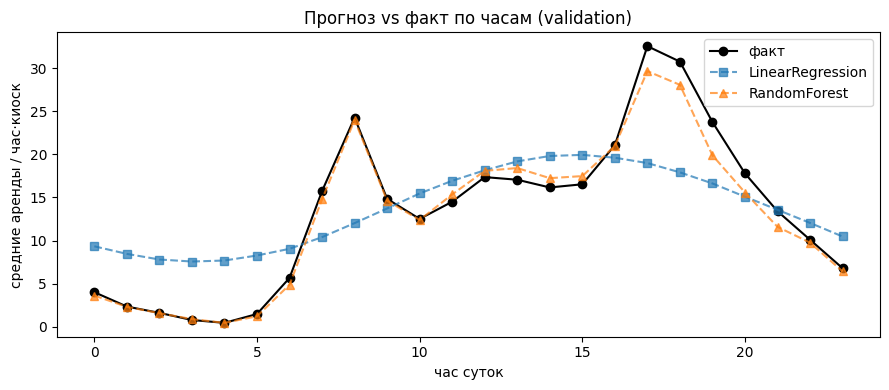

In [19]:
# Профиль по часам: ловит ли RF утренний и вечерний пик, которые baseline недооценивал?
by_hour = (val.assign(LR=np.clip(baseline.predict(X_val), 0, None), RF=rf_pred)
              .groupby("hour_of_day")[[TARGET, "LR", "RF"]].mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_hour.index, by_hour[TARGET], "o-", color="black", label="факт")
ax.plot(by_hour.index, by_hour["LR"], "s--", alpha=0.7, label="LinearRegression")
ax.plot(by_hour.index, by_hour["RF"], "^--", alpha=0.7, label="RandomForest")
ax.set_xlabel("час суток")
ax.set_ylabel("средние аренды / час·киоск")
ax.set_title("Прогноз vs факт по часам (validation)")
ax.legend()
plt.tight_layout(); plt.show()

**Вывод:** RandomForest — крупный скачок ровно на той слабости, что диагностировал baseline.

- **R² 0.35 → 0.76**, **MAE 7.12 → 3.73**, **RMSE 9.05 → 5.46** (validation) — без какого-либо тюнинга, дефолтные гиперпараметры.
- На графике: утренний (8:00) и вечерний (17–18:00) пики, которые линейная модель срезала почти вдвое, RF восстанавливает; тихие ночные часы больше не переоценивает. Дерево выучило `час × будни` и `час × погода` само, без явных кросс-фич.
- `RMSE/MAE` вырос (1.27 → 1.46): средняя ошибка упала сильнее пиковой — остаточный хвост теперь в редких всплесках, а не в систематическом срезе пиков.
- Feature importances: доминирует `hour_of_day` (≈0.54), затем тренд `days_since_launch` и `location_id` — согласуется с находками EDA.

Следующий раунд — **#4 `XGBRegressor`** (gradient boosting): обычно ещё точнее на тех же взаимодействиях.